In [1]:
import pandas as pd

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data Loading

In [2]:
df = pd.read_csv("/content/train.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Initial Data Inspection (EDA)

# Data Cleaning and Feature Engineering

In [6]:
df['Cabin'].isnull().sum()

np.int64(687)

In [11]:
df['Age'].isnull().sum()

np.int64(177)

In [12]:
df['Embarked'].isnull().sum()

np.int64(2)

In [14]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


In [15]:
df['Pclass'].value_counts()

,count
Pclass,
3,491
1,216
2,184


In [16]:
df['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [19]:
df['SibSp'].isnull().sum()
df['SibSp'].value_counts()

,count
SibSp,
0,608
1,209
2,28
4,18
3,16
8,7
5,5


In [21]:
df['Parch'].value_counts()

,count
Parch,
0,678
1,118
2,80
5,5
3,5
4,4
6,1


In [29]:
df.drop(columns = ['Cabin'] , inplace = True)

In [30]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [31]:
df.drop(columns = ['PassengerId','Name','Ticket',], inplace = True)

In [32]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [33]:
df['Embarked'].fillna('S', inplace = True)

/tmp/ipykernel_7322/1144286666.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna('S', inplace = True)


In [34]:
df['Embarked'].isnull().sum()

np.int64(0)

In [35]:
df['Age'].fillna(df['Age'].median(), inplace = True)

/tmp/ipykernel_7322/3612560828.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace = True)


In [37]:
df['Age'].isnull().sum()

np.int64(0)

In [42]:
df['familySize'] = df['SibSp'] + df['Parch'] + 1

In [43]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,familySize
0,0,3,male,22.0,1,0,7.2500,S,2
1,1,1,female,38.0,1,0,71.2833,C,2
2,1,3,female,26.0,0,0,7.9250,S,1
3,1,1,female,35.0,1,0,53.1000,S,2
4,0,3,male,35.0,0,0,8.0500,S,1


In [44]:
df.drop(columns = ['Fare','SibSp','Parch'], inplace = True)

In [45]:
df.head()

,Survived,Pclass,Sex,Age,Embarked,familySize
0,0,3,male,22.0,S,2
1,1,1,female,38.0,C,2
2,1,3,female,26.0,S,1
3,1,1,female,35.0,S,2
4,0,3,male,35.0,S,1


In [46]:
pd.get_dummies(df, columns=['Sex'], drop_first=True, dtype=int)


,Survived,Pclass,Age,Embarked,familySize,Sex_male
0,0,3,22.0,S,2,1
1,1,1,38.0,C,2,0
2,1,3,26.0,S,1,0
3,1,1,35.0,S,2,0
4,0,3,35.0,S,1,1
...,...,...,...,...,...,...
886,0,2,27.0,S,1,1
887,1,1,19.0,S,1,0
888,0,3,28.0,S,4,0
889,1,1,26.0,C,1,1


In [48]:
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True, dtype=int)


In [49]:
df.head()

,Survived,Pclass,Sex,Age,familySize,Embarked_Q,Embarked_S
0,0,3,male,22.0,2,0,1
1,1,1,female,38.0,2,0,0
2,1,3,female,26.0,1,0,1
3,1,1,female,35.0,2,0,1
4,0,3,male,35.0,1,0,1


In [50]:
df['Sex'] = df['Sex'].map({'male':0, 'female':1})

In [51]:
df.head()

,Survived,Pclass,Sex,Age,familySize,Embarked_Q,Embarked_S
0,0,3,0,22.0,2,0,1
1,1,1,1,38.0,2,0,0
2,1,3,1,26.0,1,0,1
3,1,1,1,35.0,2,0,1
4,0,3,0,35.0,1,0,1


# Data Splitting

In [55]:
X = df[['Embarked_Q','Embarked_S','Sex','Age','familySize','Pclass']]
Y = df['Survived']

In [56]:
from sklearn.model_selection import train_test_split

In [59]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42,
    stratify=Y
)

In [61]:
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape:  {X_test.shape}")

Training features shape: (712, 6)
Testing features shape:  (179, 6)


# Decision Tree Model Training and Evaluation

In [63]:
from sklearn.tree import DecisionTreeClassifier


In [64]:
model = DecisionTreeClassifier(max_depth=5, min_samples_split=2, random_state=42)

In [66]:
model.fit(X_train, Y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [67]:
Y_pred = model.predict(X_test)

In [68]:
from sklearn.metrics import accuracy_score

In [69]:
accuracy = accuracy_score(Y_test, Y_pred)
print(accuracy)

0.770949720670391


In [70]:
from sklearn.metrics import confusion_matrix

In [71]:
matrix = confusion_matrix(Y_test, Y_pred)
print(matrix)

[[101   9]
 [ 32  37]]


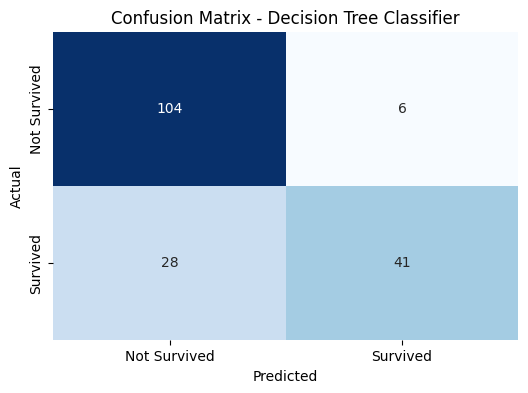

In [86]:
plt.figure(figsize=(6, 4))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree Classifier')
plt.show()

# Random Forest Model Training and Evaluation

In [72]:
from sklearn.ensemble import RandomForestClassifier


In [74]:
model = RandomForestClassifier(max_depth=5, min_samples_split=2, random_state=42)

In [77]:
model.fit(X_train, Y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [78]:
Y_pred = model.predict(X_test)

In [79]:
matrix = confusion_matrix(Y_test, Y_pred)
print(matrix)

[[104   6]
 [ 28  41]]


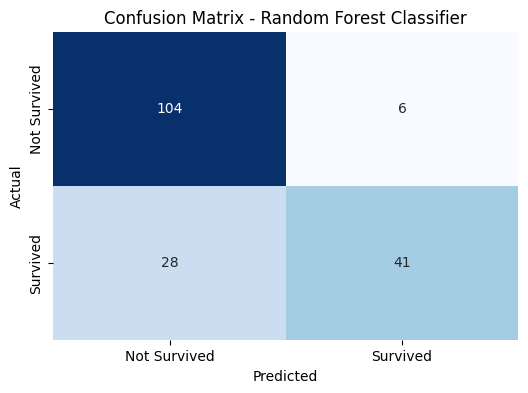

In [87]:
plt.figure(figsize=(6, 4))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest Classifier')
plt.show()

In [81]:
accuracy = accuracy_score(Y_test, Y_pred)
print(accuracy)

0.8100558659217877


In [82]:
from sklearn.metrics import classification_report

In [83]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.79      0.95      0.86       110
           1       0.87      0.59      0.71        69

    accuracy                           0.81       179
   macro avg       0.83      0.77      0.78       179
weighted avg       0.82      0.81      0.80       179



# Conclusion

In [84]:
df['Survived'].value_counts()

,count
Survived,
0,549
1,342
